### Import necessary packages

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import warnings

# import check_data

warnings.filterwarnings('ignore')

# Paths
data_path = os.path.join('.', 'data', '')
output_path = os.path.join('.', 'output', '')

# Configuration
n_splits = 5
random_seed = 42
# model_types = ['RF', 'GBDT', 'Voting', 'Averaging']
# model_types = [model_types[2]]  # Choose model type here: 'RF', 'GBDT', 'Voting', 'Averaging' # for testing


### Load the datasets

In [13]:
train_data = pd.read_csv(f"{data_path}bank_marketing_train.csv")
test_data = pd.read_csv(f"{data_path}bank_marketing_test.csv")
# train_data = pd.read_csv(f"bank_marketing_train.csv")
# test_data = pd.read_csv(f"bank_marketing_test.csv")

### Check data

In [14]:
# ============================================================
#                  1. 基本信息表格
# ============================================================

# 列名
columns_df = pd.DataFrame(train_data.columns, columns=["Column Name"])
print("📌 列名（Columns）")
display(columns_df)

# 数据类型
dtypes_df = pd.DataFrame(train_data.dtypes, columns=["Data Type"])
print("📌 数据类型（Dtypes）")
display(dtypes_df)

# 缺失值 / 非空 / 缺失率
missing_df = pd.DataFrame({
    "Non-Null Count": train_data.notnull().sum(),
    "Missing Count": train_data.isnull().sum(),
    "Missing Rate (%)": (train_data.isnull().mean() * 100).round(2)
})
print("📌 缺失值情况（Missing Values）")
display(missing_df)

# 唯一值个数
unique_df = pd.DataFrame({
    "Unique Count": train_data.nunique()
})
print("📌 唯一值数量（Unique Values）")
display(unique_df)

# 数值变量统计摘要
numeric_stats = train_data.describe().T
print("📌 数值变量统计摘要（Numeric Stats）")
display(numeric_stats)

# 类别变量统计摘要
categorical_stats = train_data.describe(include='object').T
print("📌 类别变量统计摘要（Categorical Stats）")
display(categorical_stats)

📌 列名（Columns）


,Column Name
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week


📌 数据类型（Dtypes）


,Data Type
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


📌 缺失值情况（Missing Values）


...

,Unique Count
age,77
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5


📌 数值变量统计摘要（Numeric Stats）


,count,mean,std,min,25%,50%,75%,max
age,26246.0,40.154538,10.450543,17.0000,32.0000,38.0000,47.0000,98.0000
campaign,26246.0,2.665740,2.878690,1.0000,1.0000,2.0000,3.0000,56.0000
pdays,26246.0,959.649051,193.732256,0.0000,999.0000,999.0000,999.0000,999.0000
previous,26246.0,0.181704,0.506030,0.0000,0.0000,0.0000,0.0000,7.0000
emp.var.rate,26246.0,0.059598,1.578188,-3.4000,-1.8000,1.1000,1.4000,1.4000
cons.price.idx,26246.0,93.580828,0.586050,92.2010,93.0750,93.8760,93.9940,94.7670
cons.conf.idx,26246.0,-40.491404,4.646433,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000
euribor3m,26246.0,3.597076,1.743984,0.6340,1.3340,4.8570,4.9610,5.0450
nr.employed,26246.0,5165.540197,73.224175,4963.6000,5099.1000,5191.0000,5228.1000,5228.1000
feature_1,26246.0,inf,NaN,1.3874,1.3874,2.3884,3.3894,inf


📌 类别变量统计摘要（Categorical Stats）


,count,unique,top,freq
job,26246,12,admin.,6582
marital,26246,4,married,15876
education,26246,8,university.degree,7616
default,26246,3,no,20691
housing,26246,3,yes,13694
loan,26246,3,no,21366
contact,26246,2,cellular,16318
month,26246,10,may,8855
day_of_week,26246,5,mon,5487
poutcome,26246,3,nonexistent,22493


In [15]:
# ============================================================
#              2. 异常值检测（IQR）
# ============================================================

numeric_cols = train_data.select_dtypes(include=[np.number]).columns

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    return len(outliers), lower, upper

print("\n===== 异常值检测（基于 IQR） =====")
for col in numeric_cols:
    count, lower, upper = detect_outliers(train_data, col)
    print(f"{col}: {count} 个异常值 (lower={lower:.2f}, upper={upper:.2f})")


===== 异常值检测（基于 IQR） =====
age: 296 个异常值 (lower=9.50, upper=69.50)
campaign: 1667 个异常值 (lower=-2.00, upper=6.00)
pdays: 1040 个异常值 (lower=999.00, upper=999.00)
previous: 3753 个异常值 (lower=0.00, upper=0.00)
emp.var.rate: 0 个异常值 (lower=-6.60, upper=6.20)
cons.price.idx: 0 个异常值 (lower=91.70, upper=95.37)
cons.conf.idx: 289 个异常值 (lower=-52.15, upper=-26.95)
euribor3m: 0 个异常值 (lower=-4.11, upper=10.40)
nr.employed: 0 个异常值 (lower=4905.60, upper=5421.60)
feature_1: 2762 个异常值 (lower=-1.62, upper=6.39)
feature_2: 250 个异常值 (lower=10.89, upper=74.89)


可安全绘图的数值列： ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'feature_1', 'feature_2']


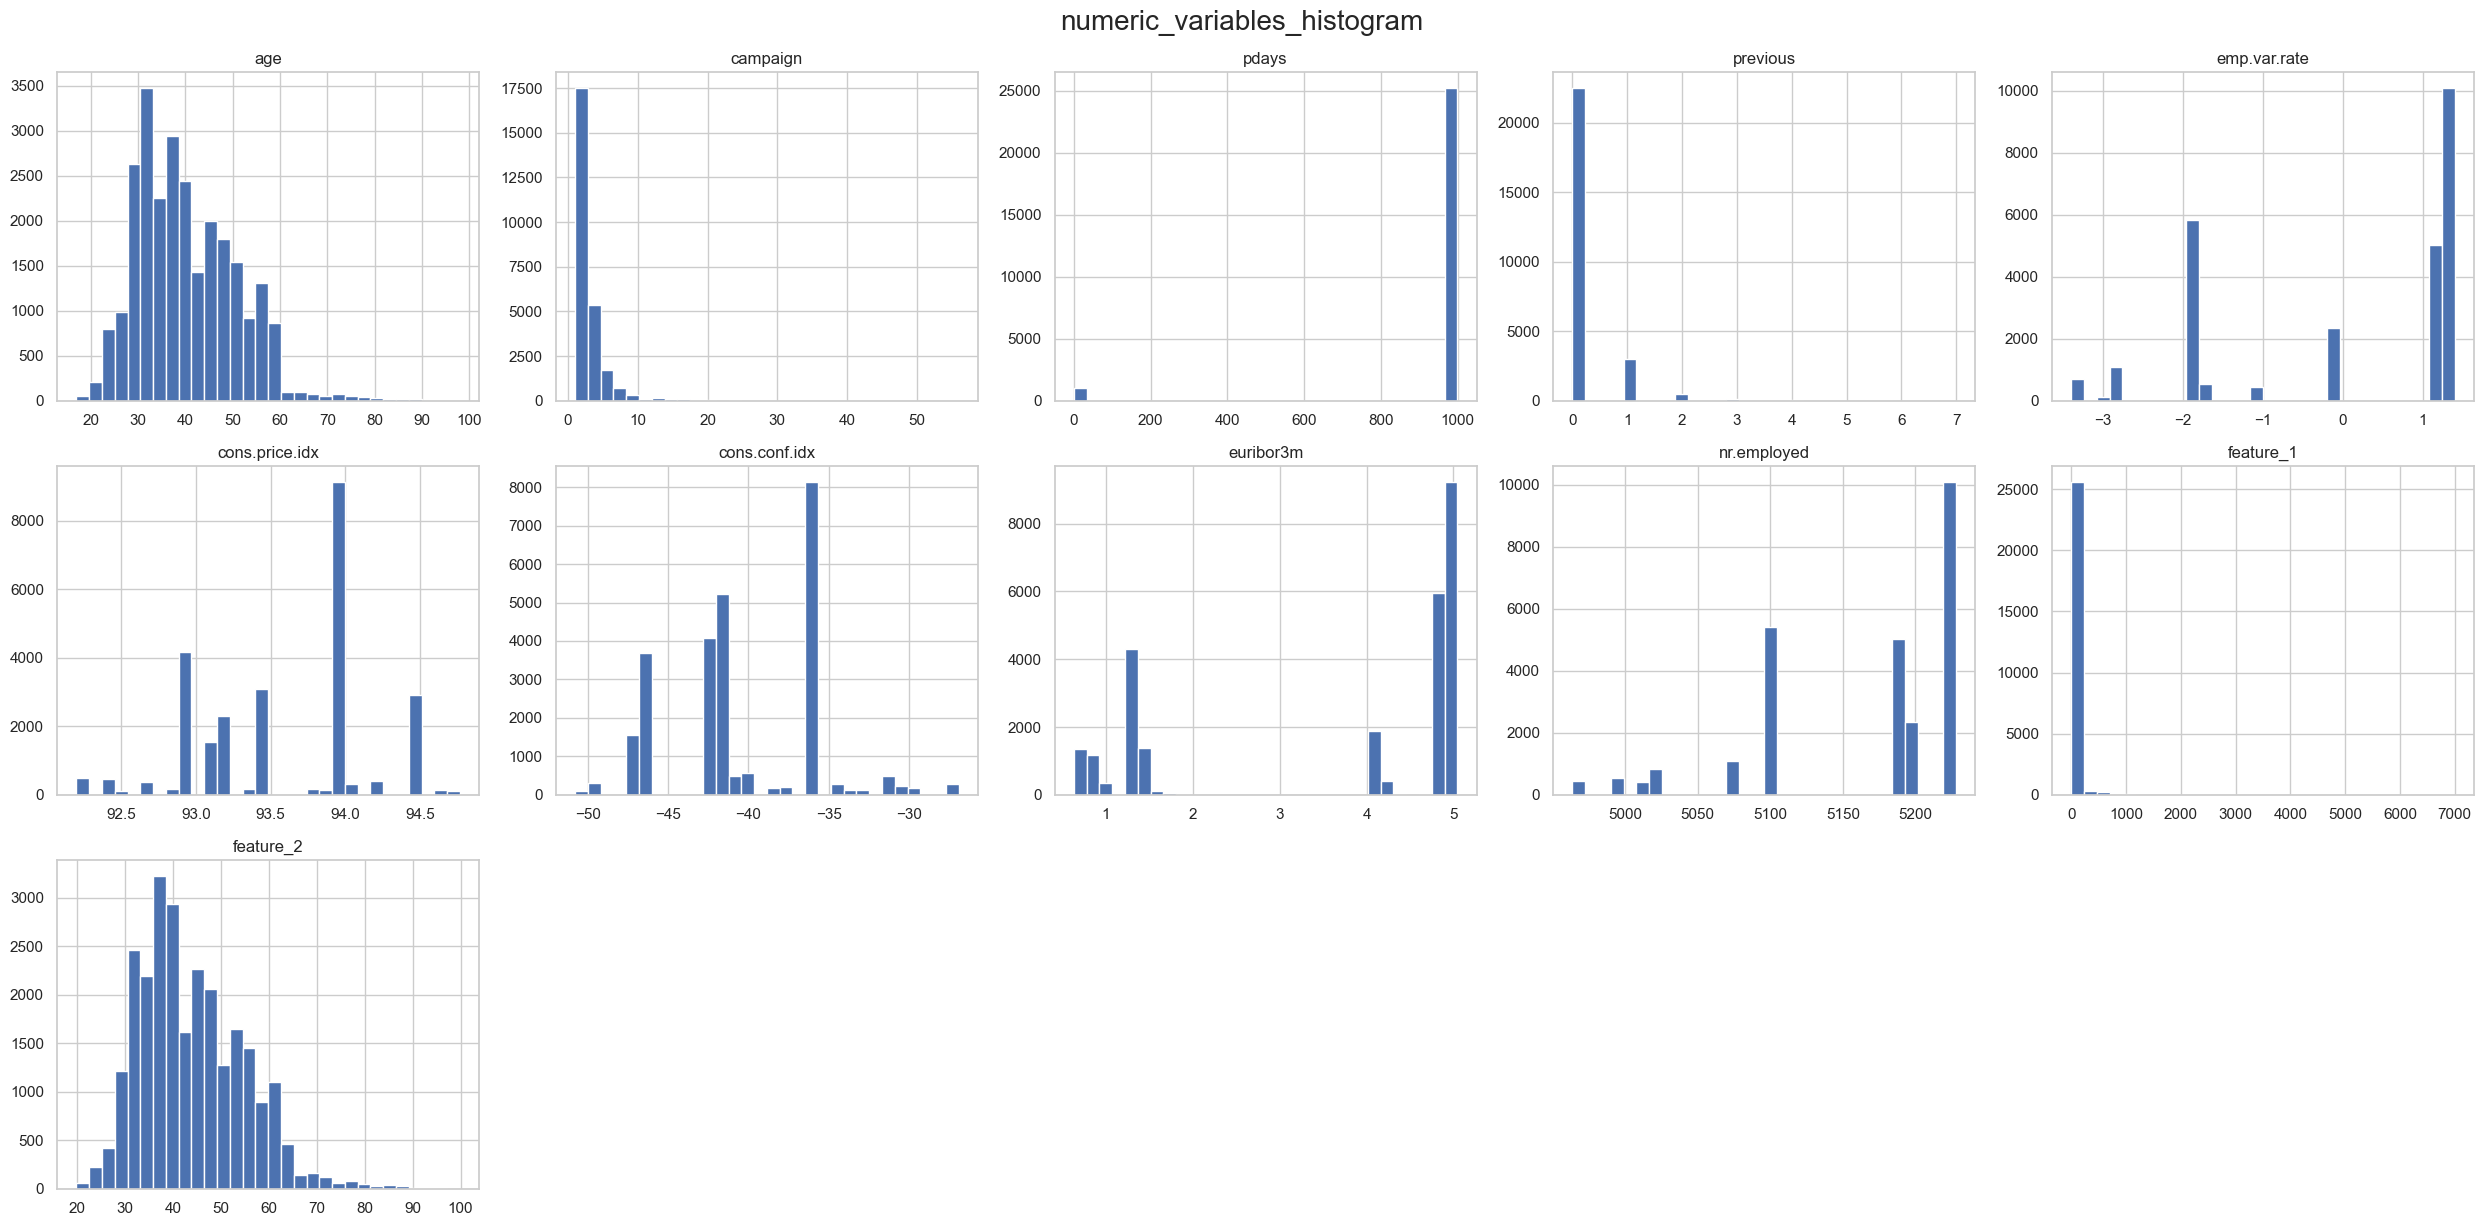

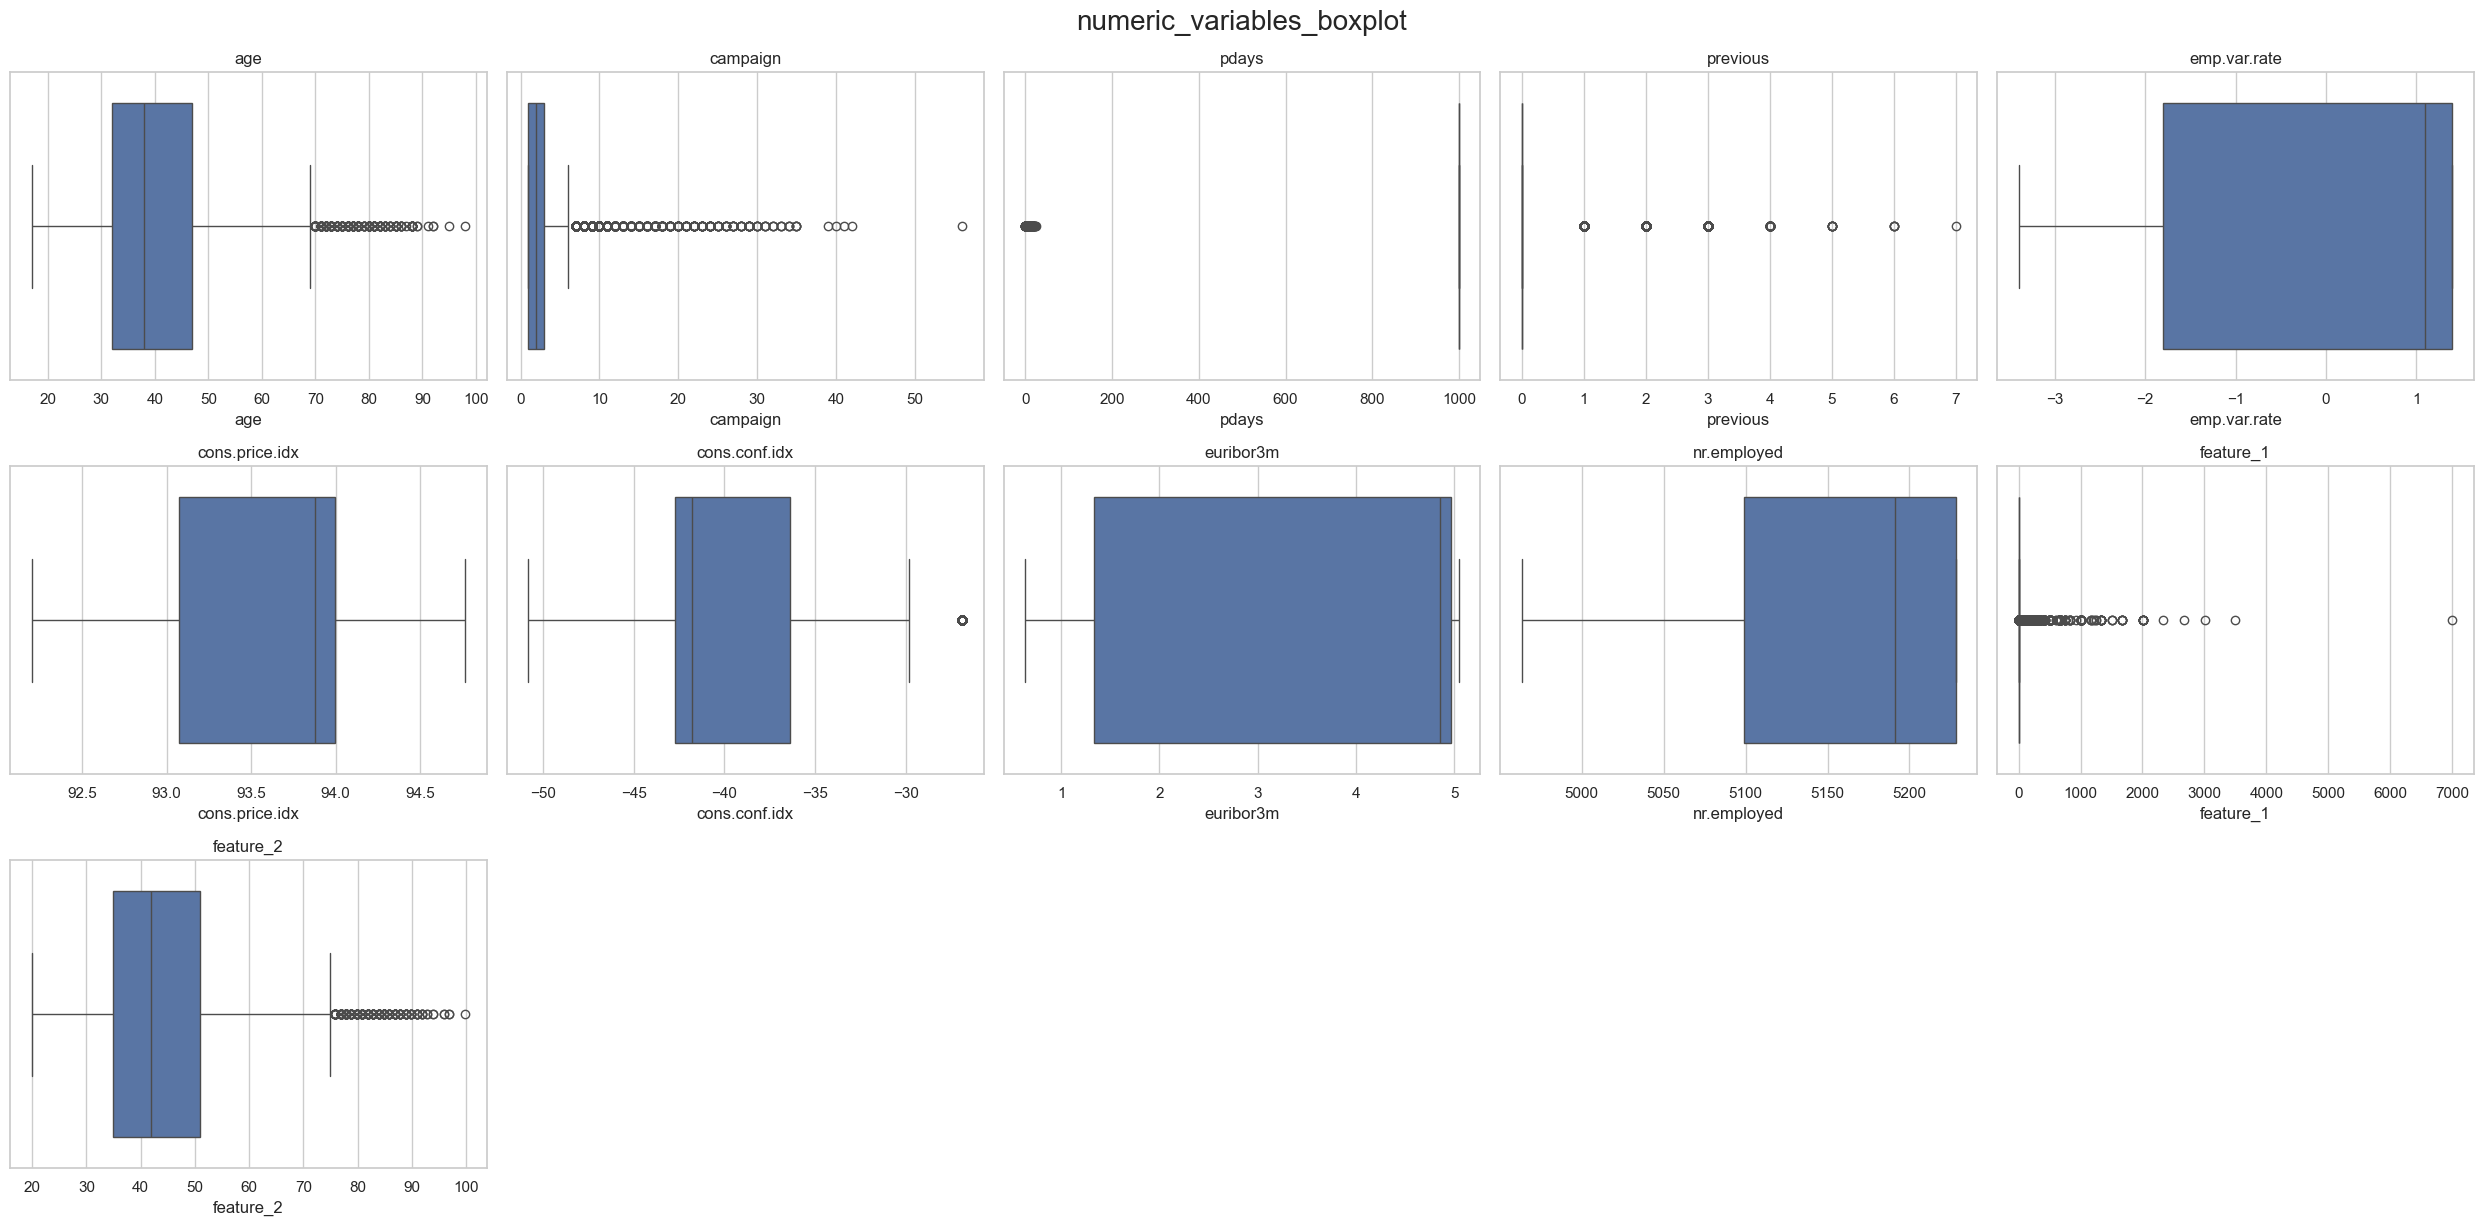

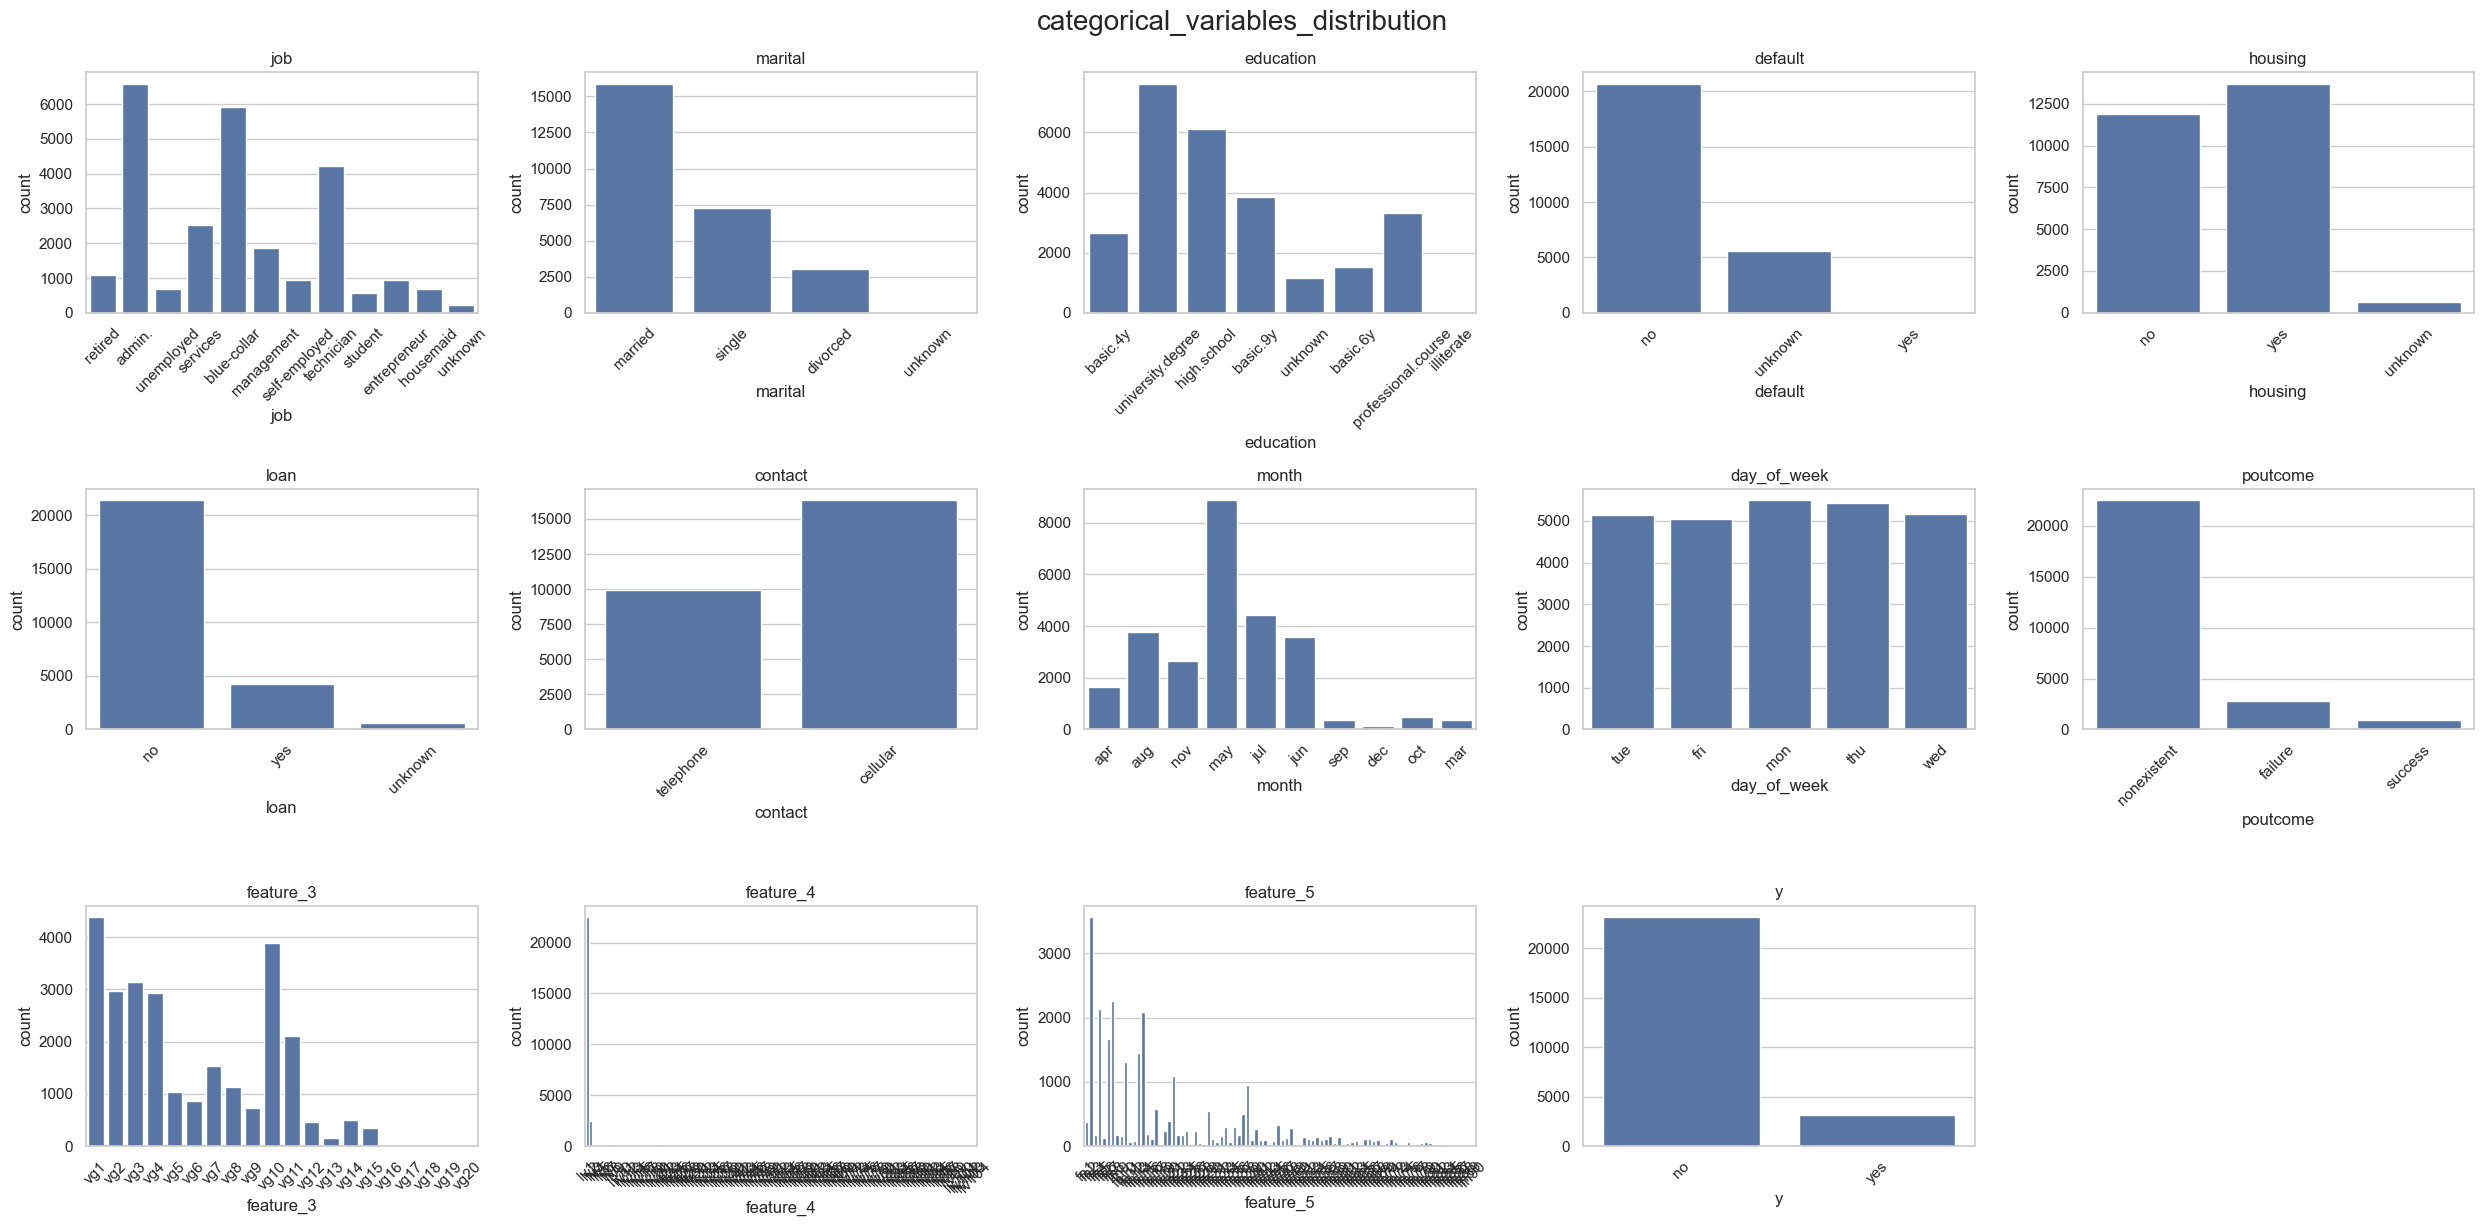

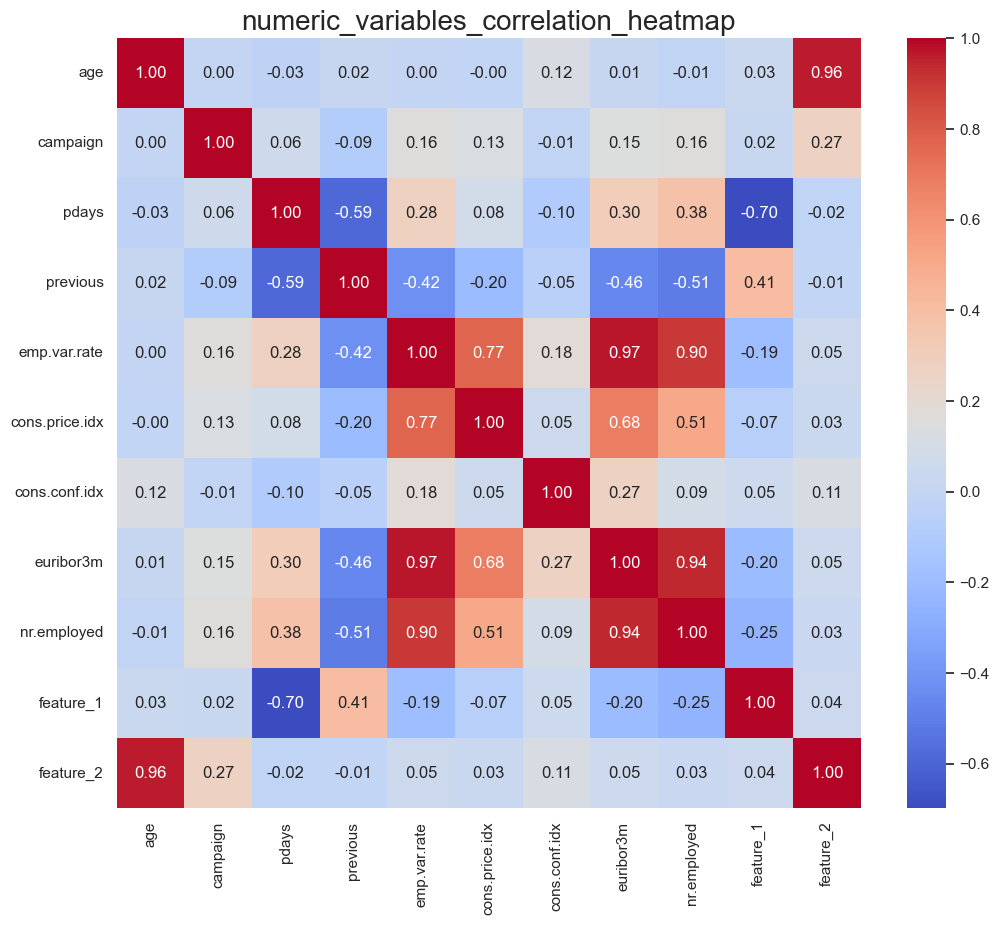

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ============================================================
#  1. 自动筛选可绘制的数值列（跳过 inf / -inf / all-NaN）
# ============================================================
safe_numeric_cols = []
for col in numeric_cols:
    vals = train_data[col]
    if np.isfinite(vals).sum() > 0:     # 至少有一个合法值
        safe_numeric_cols.append(col)

print("可安全绘图的数值列：", safe_numeric_cols)

# ============================================================
#  2. 数值变量直方图（每行 5 个）
# ============================================================

cols_per_row = 5
n = len(safe_numeric_cols)
rows = int(np.ceil(n / cols_per_row))

plt.figure(figsize=(5 * cols_per_row, 4 * rows))

for i, col in enumerate(safe_numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    vals = train_data[col][np.isfinite(train_data[col])]
    plt.hist(vals, bins=30)
    plt.title(col)
    plt.tight_layout()

plt.suptitle("numeric_variables_histogram", fontsize=20, y=1.02)
plt.savefig(f'{output_path}numeric_variables_histogram.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
#  3. 数值变量箱线图（每行 5 个）
# ============================================================

plt.figure(figsize=(5 * cols_per_row, 4 * rows))

for i, col in enumerate(safe_numeric_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    vals = train_data[col][np.isfinite(train_data[col])]
    sns.boxplot(x=vals)
    plt.title(col)
    plt.tight_layout()

plt.suptitle("numeric_variables_boxplot", fontsize=20, y=1.02)
plt.savefig(f'{output_path}numeric_variables_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
#  4. 类别变量频数图（每行 5 个）
# ============================================================

categorical_cols = train_data.select_dtypes(include=['object']).columns
n_cat = len(categorical_cols)
rows_cat = int(np.ceil(n_cat / cols_per_row))

plt.figure(figsize=(5 * cols_per_row, 4 * rows_cat))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(rows_cat, cols_per_row, i)
    sns.countplot(data=train_data, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.suptitle("categorical_variables_distribution", fontsize=20, y=1.02)
plt.savefig(f'{output_path}categorical_variables_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# ============================================================
#  5. 数值变量相关性热力图
# ============================================================

corr_data = train_data[safe_numeric_cols].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("numeric_variables_correlation_heatmap", fontsize=20)
plt.savefig(f'{output_path}numeric_variables_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


### Data preprocess

In [6]:
# def preprocess_data(df):
#     categorical_columns = ['job', 'marital', 'education', 'default', 'housing', 
#                             'loan', 'contact', 'month', 'day_of_week', 'poutcome',
#                             'feature_3', 'feature_4', 'feature_5']
#     for col in categorical_columns:
#         le = LabelEncoder()
#         df[col] = le.fit_transform(df[col].astype(str))
#     df['pdays'] = df['pdays'].replace(999, -1)
#     # Replace infinite values with median of the column
#     df['feature_1'].replace([np.inf, -np.inf], df['feature_1'].median(), inplace=True)
#     # Fill missing values with median
#     df['campaign'].fillna(df['campaign'].median(), inplace=True)
#     df['feature_1'].fillna(df['feature_1'].median(), inplace=True)
#     df['feature_2'].fillna(df['feature_2'].median(), inplace=True)

# preprocess_data(train_data)
# preprocess_data(test_data)
# X_train = train_data.drop('y', axis=1)
# y_train = train_data['y']
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def preprocess_data(df, is_train=True, stats=None):
    df = df.copy()
    df['pdays_recency'] = 1 / (df['pdays'] + 1)
    df.drop('pdays', axis=1, inplace=True)

    df['feature_1'] = df['feature_1'].replace([np.inf, -np.inf], np.inf)
    df['feature_1_transformed'] = 1 / df['feature_1']
    df['feature_1_transformed'] = df['feature_1_transformed'].replace(0.0, 0)
    df.drop('feature_1', axis=1, inplace=True)

    numeric_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 
                    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 
                    'nr.employed', 'feature_2', 'pdays_recency', 
                    'feature_1_transformed']
    
    if is_train:
        means = df[numeric_cols].mean()
        stats = {'means': means}
    else:
        means = stats['means']
    
    df[numeric_cols] = df[numeric_cols].fillna(means)

    education_map = {
        'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
        'high.school': 4, 'professional.course': 5, 'university.degree': 6,
        'unknown': np.nan
    }
    df['education_numeric'] = df['education'].map(education_map)

    if is_train:
        edu_mode = df['education_numeric'].mode()[0]
        stats['edu_mode'] = edu_mode
    else:
        edu_mode = stats['edu_mode']
        
    df['education_numeric'].fillna(edu_mode, inplace=True)
    df.drop('education', axis=1, inplace=True)
    
    map_dict = {'yes': 1, 'no': 0, 'unknown': -1}
    for col in ['default', 'housing', 'loan']:
        df[col] = df[col].map(map_dict).fillna(-1)

    one_hot_cols = ['job', 'marital', 'contact', 'month', 'day_of_week', 
                    'poutcome', 'feature_3', 'feature_4', 'feature_5']
    
    for col in one_hot_cols:
        df[col] = df[col].astype(str)
        
    df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
    
    scale_cols = numeric_cols + ['education_numeric']
    
    if is_train:
        scaler = StandardScaler()
        df[scale_cols] = scaler.fit_transform(df[scale_cols])
        stats['scaler'] = scaler
    else:
        scaler = stats['scaler']
        df[scale_cols] = scaler.transform(df[scale_cols])
        
    return df, stats

train_processed, train_stats = preprocess_data(train_data, is_train=True)
test_processed, _ = preprocess_data(test_data, is_train=False, stats=train_stats)

final_columns = train_processed.columns.tolist()
if 'y' in final_columns: 
    final_columns.remove('y')

test_processed = test_processed.reindex(columns=final_columns, fill_value=0)

X_train = train_processed.drop('y', axis=1)
y_train = train_processed['y'].map({'yes': 1, 'no': 0}) 

X_test = test_processed 

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")


# X_train.join(y_train).to_csv('train_final_processed.csv', index=False)
# X_test.to_csv('test_final_processed.csv', index=False)

X_train shape: (26246, 256)
X_test shape:  (8000, 256)


In [7]:
# dt = DecisionTreeClassifier(random_state=random_seed)
# dt.fit(X_train, y_train)
# y_pred = dt.predict_proba(X_train)
# assert type(y_pred) == np.ndarray
# print(y_pred.shape)

### Model definition

In [8]:
# class MyEnsembleModel:
#     def __init__(self, method, n_estimators, random_state=42):
#         self.method = method
#         self.random_state = random_state
#         if n_estimators % 4 != 0:
#             raise ValueError("n_estimators must be a multiple of 4")
#         self.models = []
#         for _ in range(n_estimators // 4):
#             self.models += [
#                 DecisionTreeClassifier(random_state=self.random_state),
#                 LogisticRegression(random_state=self.random_state),
#                 GaussianNB(),
#                 KNeighborsClassifier(),
#             ]
    
#     def fit(self, X, y):
#         for model in self.models:
#             model.fit(X, y)
#         return self
    
#     def predict(self, X):
#         probas = self.predict_proba(X) # shape (n_samples, n_classes)
#         assert type(probas) == np.ndarray
#         preds = np.argmax(probas, axis=-1) # shape (n_samples,)
#         return preds
    
#     def predict_proba(self, X):
#         probas = np.zeros((len(self.models), X.shape[0], 2)) # shape (n_models, n_samples, n_classes)
#         for i, model in enumerate(self.models):
#             proba = model.predict_proba(X) # shape (n_samples, n_classes)
#             probas[i] = proba
        
#         if self.method == 'voting':
#             votes = (probas >= 0.5).astype(int) # shape (n_models, n_samples, n_classes)
#             return np.sum(votes, axis=0) / len(self.models) # shape (n_samples, n_classes)
        
#         elif self.method == 'averaging':
#             return np.mean(probas, axis=0)
        
#         else:
#             raise ValueError("Method cannot be found!")
    
#     def score(self, X, y):
#         preds = self.predict(X) == 'yes'
#         y_label = np.array(y) == 'yes'
#         return accuracy_score(y_label, preds)

### Init models

In [9]:
# init models
model = {}
model['DecisionTree'] = DecisionTreeClassifier(random_state=random_seed)
model['LogisticRegression'] = LogisticRegression(random_state=random_seed, max_iter=1000)
model['NaiveBayes'] = GaussianNB()
model['KNN'] = KNeighborsClassifier(n_neighbors=5)
model['SVM'] = SVC(probability=True, random_state=random_seed)

# Ensemble Models
model['RF'] = RandomForestClassifier(n_estimators=100, random_state=random_seed)
model['GBDT'] = GradientBoostingClassifier(n_estimators=100, random_state=random_seed)
estimators = [
    ('dt', model['DecisionTree']),
    ('lr', model['LogisticRegression']),
    ('nb', model['NaiveBayes']),
    ('knn', model['KNN']),
    ('svm', model['SVM'])
]
# model['Voting_Sklearn'] = VotingClassifier(estimators=estimators)
model['Voting_Sklearn'] = VotingClassifier(estimators=estimators, voting='soft')
# model['Voting'] = MyEnsembleModel(n_estimators=100, method='voting', random_state=random_seed)
# model['Averaging'] = MyEnsembleModel(n_estimators=100, method='averaging', random_state=random_seed)

### Training

Training model: DecisionTree
    Validation score for fold 1: 0.8284
    AUC for fold 1: 0.6150
    Validation score for fold 2: 0.8383
    AUC for fold 2: 0.6385
    Validation score for fold 3: 0.8320
    AUC for fold 3: 0.6216
    Validation score for fold 4: 0.8329
    AUC for fold 4: 0.6221
    Validation score for fold 5: 0.8268
    AUC for fold 5: 0.6052
    Mean AUC: 0.6205
Training model: LogisticRegression
    Validation score for fold 1: 0.8901
    AUC for fold 1: 0.7919
    Validation score for fold 2: 0.8927
    AUC for fold 2: 0.8045
    Validation score for fold 3: 0.8929
    AUC for fold 3: 0.7834
    Validation score for fold 4: 0.8967
    AUC for fold 4: 0.7822
    Validation score for fold 5: 0.8937
    AUC for fold 5: 0.7968
    Mean AUC: 0.7918
Training model: NaiveBayes
    Validation score for fold 1: 0.8771
    AUC for fold 1: 0.7192
    Validation score for fold 2: 0.8752
    AUC for fold 2: 0.7406
    Validation score for fold 3: 0.8838
    AUC for fold 3: 0.7

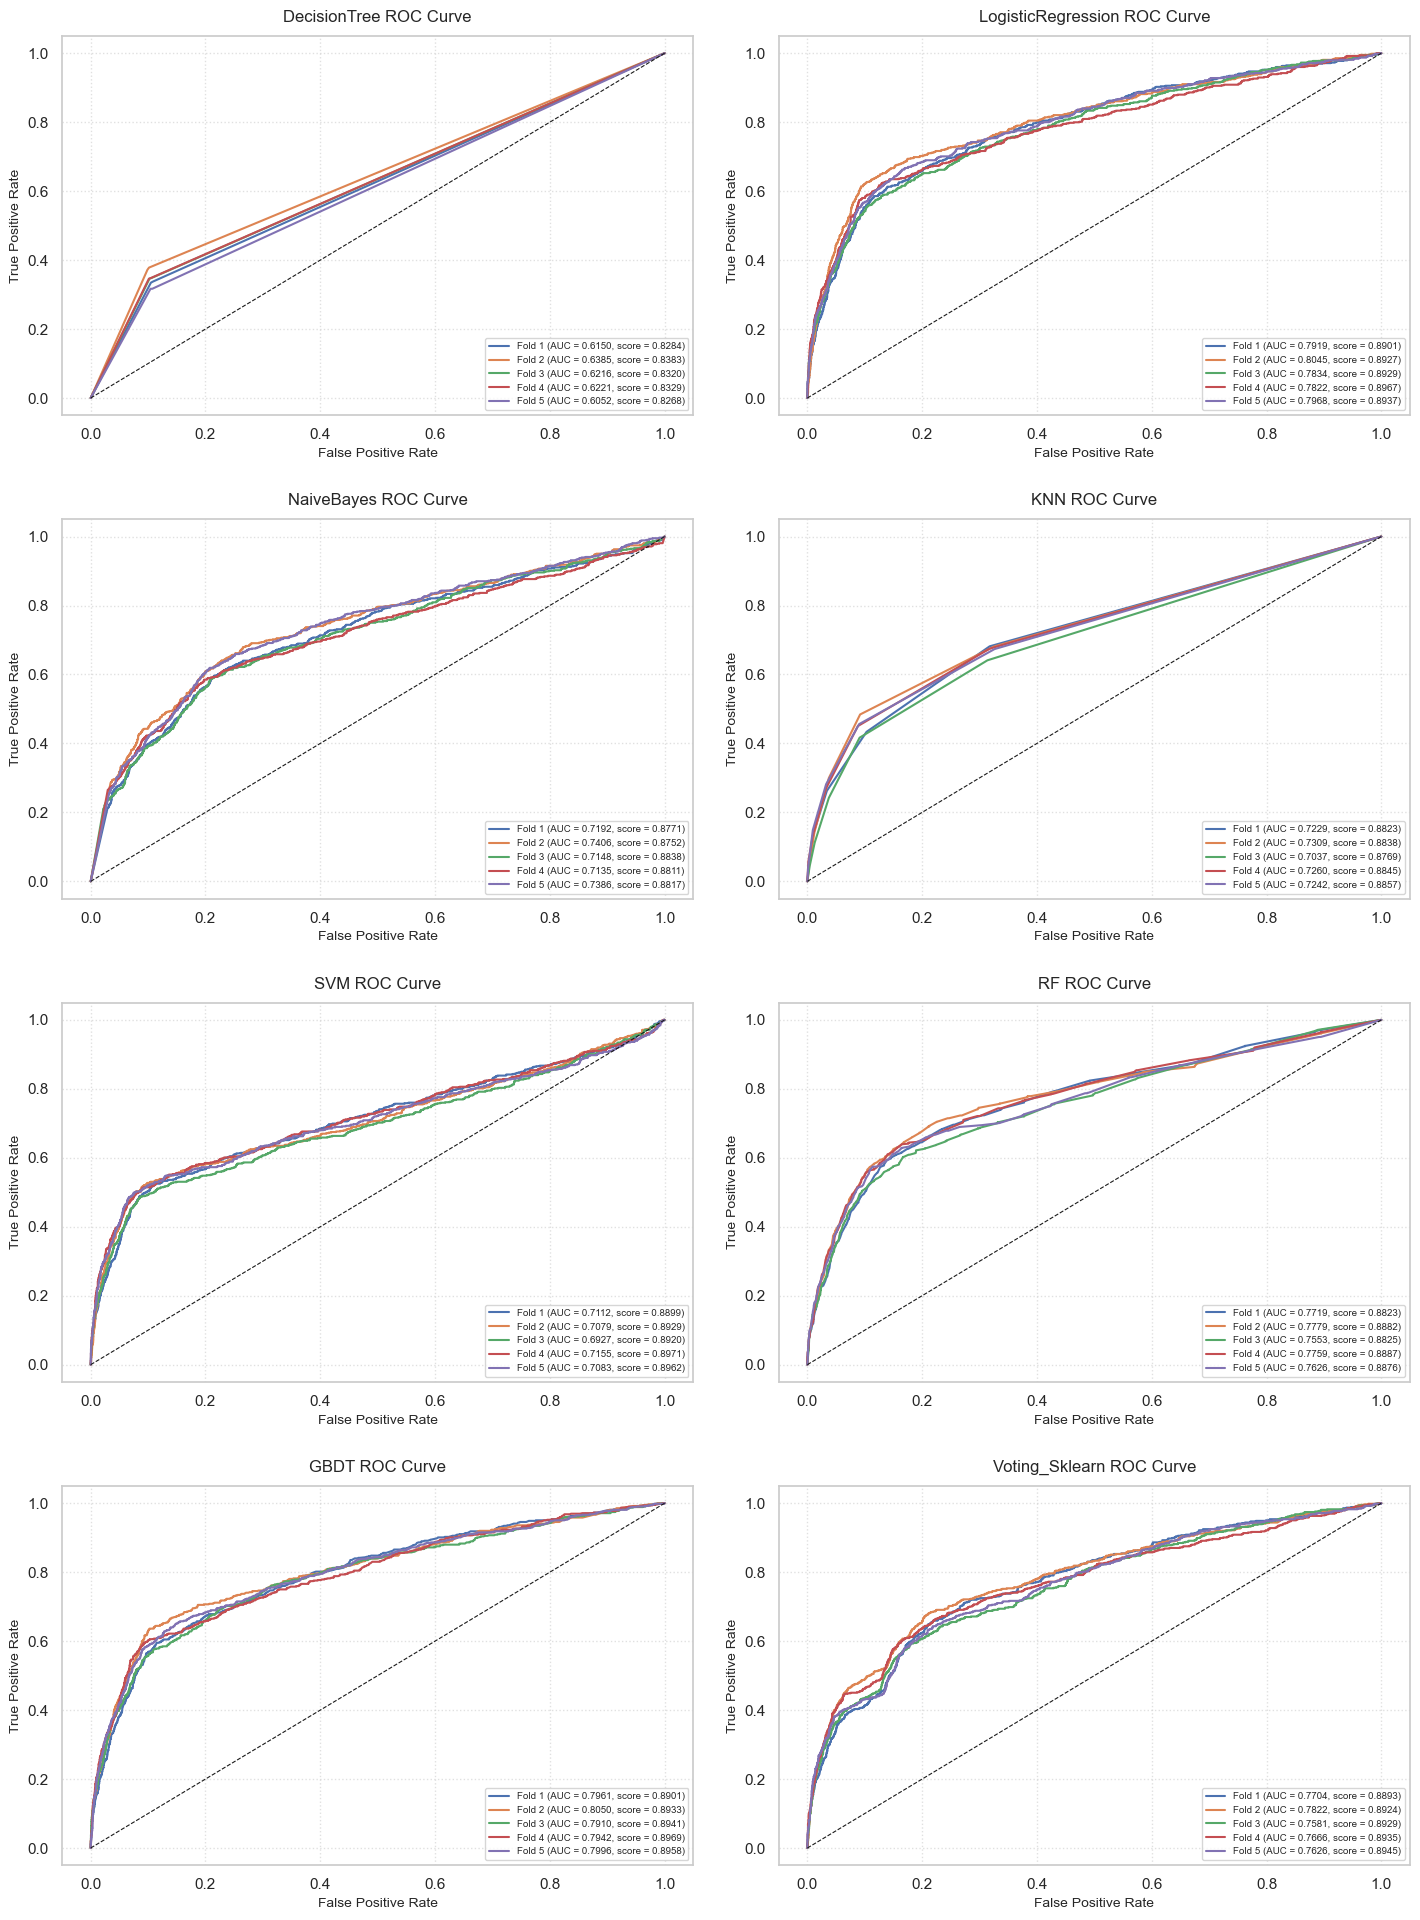

In [10]:
fig, axes = plt.subplots((len(model) + 1) // 2, 2, figsize=(15, 20))  
axes = axes.flatten()

for idx, model_type in enumerate(model.keys()):
    print(f'Training model: {model_type}')
    ax = axes[idx]

    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    auc = []

    for i, (train_index, val_index) in enumerate(kfold.split(X_train, y_train)):
        # training and validation
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
        model[model_type].fit(X_train_fold, y_train_fold)
        score = model[model_type].score(X_val_fold, y_val_fold)
        print(f"    Validation score for fold {i + 1}: {score:.4f}")

        # calculate AUC
        y_label = np.array(y_val_fold) == 1
        y_val_pred_prob = model[model_type].predict_proba(X_val_fold)
        assert type(y_val_pred_prob) == np.ndarray
        y_val_pred_prob = y_val_pred_prob[:, 1]
        auc.append(roc_auc_score(y_label, y_val_pred_prob))
        print(f"    AUC for fold {i + 1}: {auc[i]:.4f}")

        # plot ROC curve
        fpr, tpr, thresholds = roc_curve(y_label, y_val_pred_prob)
        # plt.plot(fpr, tpr, label=f'Fold {i + 1} (AUC = {auc[i]:.4f}, score = {score:.4f})')
        ax.plot(fpr, tpr, label=f'Fold {i + 1} (AUC = {auc[i]:.4f}, score = {score:.4f})')

    print(f'    Mean AUC: {np.mean(auc):.4f}')
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.set_title(f'{model_type} ROC Curve', fontsize=12, pad=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout(pad=3.0, w_pad=2.0, h_pad=2.0)
plt.savefig(f'{output_path}ensamble_model_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### Testing

In [11]:
for model_type in model.keys():
    # pred = model.predict(test_data)
    pred_prob = model[model_type].predict_proba(X_test)
    assert type(pred_prob) == np.ndarray
    pred_prob = pred_prob[:, 1]
    pd.DataFrame(pred_prob).to_csv(f'{output_path}{model_type}_test_scores.csv', index=False, header=False)